In [2]:
import numpy as np
import torch
import umap
import matplotlib.pyplot as plt

In [7]:
import torch

class BengioEnergy:
    def __init__(self, w, b, activation=torch.tanh, device="cpu"):
        """
        :param w: Weight tensor (assumed shape: (some_dim, some_dim))
        :param b: Bias tensor (assumed shape: same as input n)
        :param activation: Activation function (e.g., torch.tanh, torch.relu)
        :param device: 'cpu' or 'cuda' for GPU acceleration
        """
        self.w = w.to(device)  # Move weights to device
        self.b = b.to(device)  # Move biases to device
        self.activation = activation  # Store activation function
        self.device = device  # Store device

    def bengio_energy(self, n):
        """
        Computes the energy function.
        :param n: Input tensor (shape: batch_size x feature_dim)
        :return: Scalar energy value
        """
        n = n.to(self.device)  # Ensure input tensor is on the correct device
        act_n = self.activation(n)  # Apply activation function

        # Compute interaction term
        inter = 0.5 * torch.sum(self.w * act_n[:-1, :, None] * act_n[1:, None, :])

        # Compute energy term
        en = torch.sum(self.b * act_n)

        # Compute norm term
        norm = 0.5 * torch.sum(n**2)

        return norm - inter - en  
    
    def 

In [79]:
def find_minima(energy_fn, x_init, lr=0.01, steps=1000, grad_thresh = 1e-1):
    x = x_init.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([x], lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        energy = energy_fn(x)
        energy.backward()

        grad_norm = x.grad.norm()
        if grad_norm < grad_thresh:
            print(f"Stopping early, gradient norm {grad_norm.item()} is below threshold.")
            break
        optimizer.step()

    return x.detach(), energy_fn(x).detach()

def compute_hessian(energy_fn, x_min):
    """ Compute Hessian matrix for an energy function with an input tensor. """
    # Get the shape of x_min
    shape = x_min.shape
    
    # Flatten x_min from (num_layers, n_per_layer) to a 1D tensor
    x_flat = x_min.clone().detach().flatten().requires_grad_(True)
    
    def wrapped_energy(x_flat):
        # Reshape back to the original shape using the shape of x_min
        return energy_fn(x_flat.view(*shape))  # Use *shape to unpack the dimensions
    
    # Compute Hessian using the wrapped energy function
    hessian = torch.autograd.functional.hessian(wrapped_energy, x_flat)
    return hessian

def estimate_basin_size(hessian):
    """ Estimate the basin size using the inverse determinant of the Hessian. """
    # Use torch.slogdet to compute the determinant more stably
    sign, logdet = torch.slogdet(hessian)
    
    # If determinant is non-negative, compute inverse of determinant
    if sign == 1:
        # Exponentiate the log determinant to get the determinant and invert it
        inv_det = torch.exp(-logdet)
        return inv_det
    else:
        # If the determinant is negative (i.e., matrix is not positive-definite), return a large value
        return float('inf')


device = "cuda" if torch.cuda.is_available() else "cpu" 
n_layers, n_per_layer = 2, 64

num_tracers = 1000
init_points = [torch.distributions.Uniform(-5.0, 5.0).sample((n_layers, n_per_layer)) for _ in range(num_tracers)]

loc = 0.0
scale = 0.65

w_normal = torch.normal(mean=loc, std=scale, size=(n_layers-1, n_per_layer, n_per_layer))
#w_exp = torch.distributions.Exponential(rate=loc).sample((n_layers-1, n_per_layer, n_per_layer))
w_ln = torch.distributions.LogNormal(loc, scale).sample((n_layers-1, n_per_layer, n_per_layer))
w_uni = torch.distributions.Uniform(-1.0, 1.0).sample((n_layers-1, n_per_layer, n_per_layer))

b = torch.randn(n_layers, n_per_layer, requires_grad=True)
eng = BengioEnergy(w_normal, b, activation=torch.sigmoid, device="cpu")

energy_fn = eng.bengio_energy

minima_states = []
minima_energies = []
basin_vols = []
dist_to_basin = []
input_norm = []
min_norm = []

for i, x_init in enumerate(init_points):
    x_min, E_min = (find_minima(energy_fn, x_init))
    hess = compute_hessian(energy_fn, x_min)
    det_inv = estimate_basin_size(hess)
    dist_to_basin.append(torch.sum(torch.sqrt(torch.square(x_init - x_min))))
    input_norm.append(torch.sum(torch.sqrt(torch.square(x_init))))
    min_norm.append(torch.sum(torch.sqrt(torch.square(x_min))))
    if det_inv != float('inf'):
        basin_vols.append((i, det_inv))
    minima_states.append(x_min)
    minima_energies.append(E_min)

    if i % int((num_tracers / 10)) == 0:
        print(i)

minima_states_t = torch.stack(minima_states)

0
100
200
300
400
500
600
700
800
900


(array([1.00000e+03, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 2.00000e+00, 1.22000e+02, 1.87800e+03, 1.43900e+04,
        6.25920e+04, 1.57112e+05, 2.47688e+05, 2.52670e+05, 1.65622e+05,
        7.09120e+04, 2.08820e+04, 4.40600e+03, 6.66000e+02, 5.80000e+01]),
 array([0.        , 0.04599324, 0.09198648, 0.13797973, 0.18397297,
        0.22996621, 0.27595946, 0.3219527 , 0.36794594, 0.41393918,
        0.45993242, 0.50592566, 0.55191892, 0.59791213, 0.6439054 ,
        0.68989861, 0.73589188, 0.78188515, 0.82787836, 0.87387162,
        0.91986483]),
 <BarContainer object of 20 artists>)

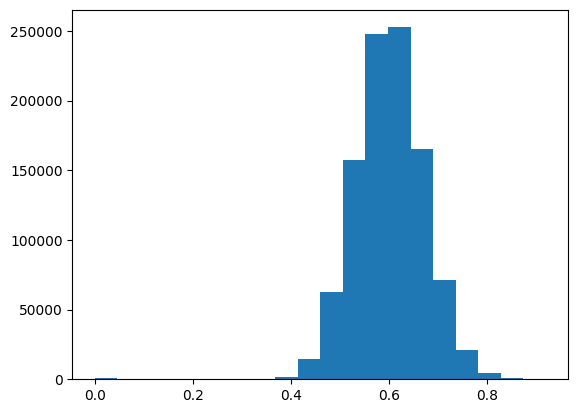

In [88]:
flat_min_states = [state.flatten() for state in minima_states]
stacked_tensors = torch.stack(flat_min_states)
distances = torch.cdist(stacked_tensors, stacked_tensors, p=2)

plt.hist(distances.flatten(), bins=20)


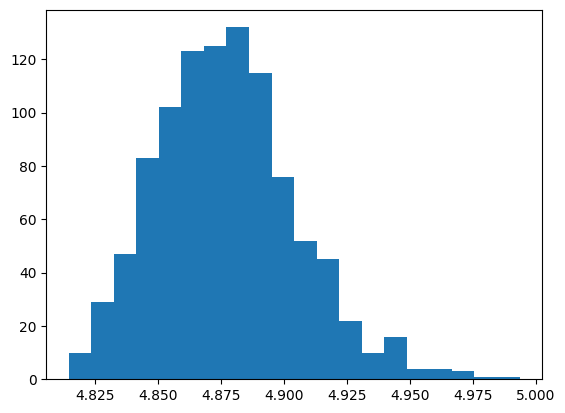

In [72]:
plt.hist(minima_energies, bins=20)

behaved_basins = []
behaved_energy = []
vol_vals = []

for i, det in basin_vols:
    behaved_basins.append(minima_states[i])
    behaved_energy.append(minima_energies[i])
    vol_vals.append(det)



#plt.scatter(behaved_energy, vol_vals)



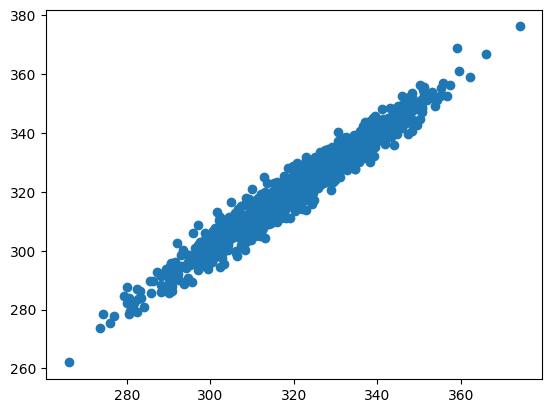

In [69]:
plt.scatter(dist_to_basin, input_norm)

(array([  9.,  17.,  60., 148., 260., 256., 172.,  61.,  15.,   2.]),
 array([31.81419373, 32.13224411, 32.45029831, 32.76834869, 33.08639908,
        33.40444946, 33.72250366, 34.04055405, 34.35860443, 34.67665863,
        34.99470901]),
 <BarContainer object of 10 artists>)

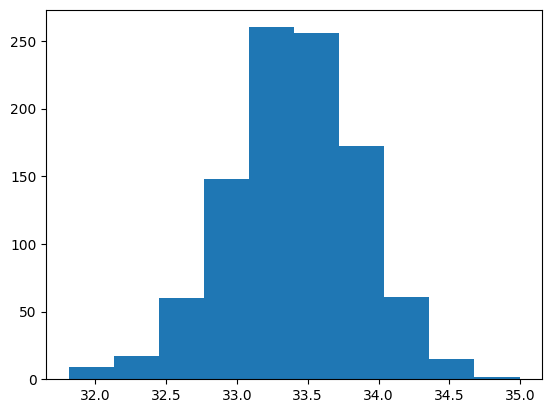

In [70]:
plt.hist(min_norm)



In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu" 
n_layers = 10
n_per_layer = 100

loc = -2.5
scale = 0.65

w_normal = torch.normal(mean=loc, std=scale, size=(n_layers-1, n_per_layer, n_per_layer))
#w_exp = torch.distributions.Exponential(rate=loc).sample((n_layers-1, n_per_layer, n_per_layer))
w_ln = torch.distributions.LogNormal(loc, scale).sample((n_layers-1, n_per_layer, n_per_layer))
b = torch.randn(n_layers, n_per_layer, requires_grad=True)
act = torch.tanh 

eng = BengioEnergy(w_ln, b, activation=torch.relu, device="cpu")

num_iterations = 10000

energies = []
neurons = []

for _ in range(num_iterations):
    n = torch.sqrt(torch.distributions.LogNormal(loc, scale).sample((n_layers, n_per_layer)))
    neurons.append(n.detach().numpy())
    energies.append(eng.bengio_energy(n).detach().numpy())

energies = np.array(energies)
neurons = np.array(neurons).reshape(num_iterations, n_layers * n_per_layer)

(10000, 1000)


(array([  1.,   1.,   0.,   2.,   1.,   3.,   2.,   3.,   5.,   5.,   2.,
          5.,   8.,   8.,   8.,  12.,  11.,  15.,  19.,  25.,  34.,  24.,
         29.,  49.,  46.,  67.,  72.,  81.,  67.,  75.,  83., 110., 114.,
        128., 156., 165., 190., 209., 223., 232., 227., 231., 255., 255.,
        274., 312., 315., 271., 299., 292., 305., 287., 298., 294., 281.,
        261., 245., 248., 231., 225., 242., 208., 184., 173., 173., 147.,
        150., 112., 138., 109., 102.,  80.,  77.,  53.,  51.,  47.,  45.,
         36.,  20.,  29.,  18.,  25.,  12.,  20.,  11.,  10.,  10.,   4.,
          3.,   3.,   2.,   4.,   1.,   1.,   1.,   0.,   1.,   1.,   0.,
          1.]),
 array([-396.18222046, -395.54980469, -394.91738892, -394.28494263,
        -393.65252686, -393.02011108, -392.38769531, -391.75524902,
        -391.12283325, -390.49041748, -389.85800171, -389.22555542,
        -388.59313965, -387.96072388, -387.32830811, -386.69589233,
        -386.06344604, -385.43103027, -384.798

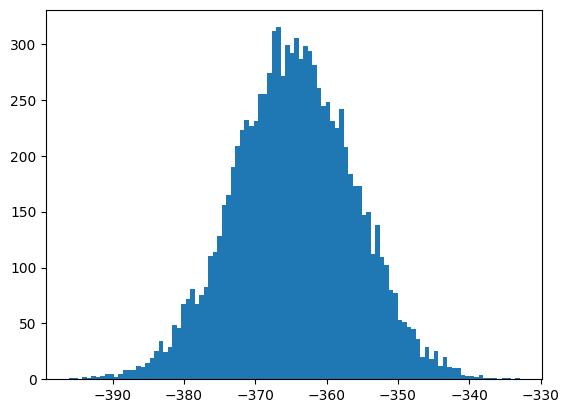

In [18]:
print(neurons.shape)
plt.hist(energies, bins=100)

In [96]:
umap_model = umap.UMAP(n_components=2)
data = umap_model.fit_transform(neurons)

/Users/collinszczepanski/Code/cris/eqprop/chenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


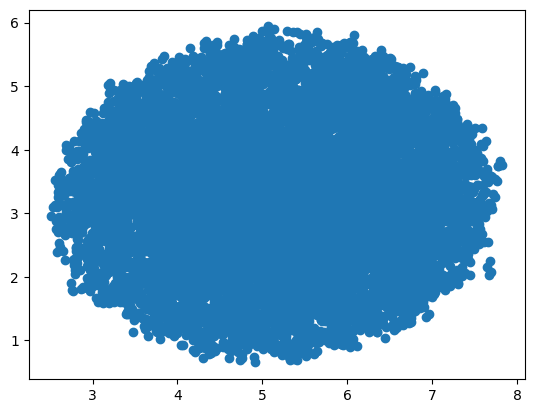

In [97]:
plt.scatter(data[:,0], data[:,1])

In [44]:
import torch

class BengioEnergy(torch.nn.Module):
    def __init__(self, w, b, act, device="cpu"):
        super().__init__()
        self.w = torch.nn.Parameter(w.to(device)) 
        self.b = torch.nn.Parameter(b.to(device))
        self.act = act
        self.device = device

    def forward(self, n):
        n = n.to(self.device) 
        act_n = self.act(n)
        
        act_n_shifted = act_n[:, 1:]  
        act_n_prev = act_n[:, :-1]  

        inter = 0.5 * torch.sum(torch.bmm(act_n_prev.unsqueeze(1), self.w.unsqueeze(0)) * act_n_shifted.unsqueeze(1))
        en = torch.sum(self.b * act_n, dim=1)
        norm = 0.5 * torch.sum(n**2, dim=1)

        return (norm - inter - en)

# Example Usage:
device = "cuda" if torch.cuda.is_available() else "cpu" 
n_layers, n_per_layer = 5, 10

w = torch.randn(n_layers-1, n_per_layer, n_per_layer, requires_grad=True)
b = torch.randn(n_layers, n_per_layer, requires_grad=True)
act = torch.tanh 

In [45]:
model = BengioEnergy(w, b, act, device=device)

num_per_batch = 32


n = torch.randn(num_per_batch, n_layers, n_per_layer, requires_grad=True, device=device) 

energy = model(n)
energy.backward() 
grad_n = n.grad
print("Gradient w.r.t n:", grad_n)

RuntimeError: batch1 must be a 3D tensor

In [ ]:
def langevin_sampling(model, n_init, lr=0.01, n_steps=100, noise_std=0.1, traj = True):
    """Perform MCMC sampling using Langevin dynamics."""
    n = n_init.clone().detach().requires_grad_(True)

    if traj:
        traj_list = []

    for step in range(n_steps):
        energy = model(n)  # Compute energy
        energy.backward()   # Compute gradient ∇E(n)
        
        # Langevin update: gradient descent + Gaussian noise
        noise = torch.randn_like(n) * noise_std
        with torch.no_grad():
            n -= (lr / 2) * n.grad + noise
            n.grad.zero_()  # Reset gradients
        
        if traj:
            traj_list.append(n)
        
        if step % 100 == 0:
            print(f"Step {step}, Energy: {energy.item()}")

    return n, traj_list

# Initialize model
w = torch.randn(2, 5, 5, requires_grad=True)
b = torch.randn(3, 5, requires_grad=True)
act = torch.tanh  
model = BengioEnergy(w, b, act)

# Initialize state n randomly
n_init = torch.randn(3, 5)

# Perform MCMC sampling
n_samples, traj = langevin_sampling(model, n_init, lr=0.01, n_steps=10000, noise_std=0.1)
print("Final sampled state:", n_samples)

traj = [ten.detach().numpy() for ten in traj]
traj = np.vstack(traj)

np.shape(traj)

In [36]:
umap_model = umap.UMAP(n_components=2)
data = umap_model.fit_transform(traj)

/Users/collinszczepanski/Code/cris/eqprop/chenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [46]:
class InferenceMachine():

    def __init__(self, w, b, act, act_prime) -> None:
        self.w = w
        self.b = b
        self.act = act
        self.act_prime = act_prime

    def bengio_energy(self, n):
        inter = 0.5*np.sum(self.w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = np.sum(self.b * self.act(n))
        norm = 0.5*np.sum(n**2)

        return norm - inter - en

    def hopfield_energy(self, n):
        inter = -0.5*np.sum(self.w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = -1.0*np.sum(self.b * self.act(n))

        return inter + en

    def hopfield_grad(self, n):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad -= self.b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], self.w + self.w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], self.w + self.w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad

    def bengio_grad(self, n):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad += n
        grad -= self.b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], self.w + self.w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], self.w + self.w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad
    
    def hopfield_interaction(self, h , x, w_x, b_x, act_x, con_ind):
        en = -1.0*(b_x.T @ act_x(x))
        inter = -1.0*(act_x(x).T @ w_x @ self.act(h[con_ind, :]))

        return inter + en

    def hopfield_interaction_grad(self, h , x, w_x, b_x, act_x, act_prime_x, con_ind, freeze):
        grad_x = np.zeros_like(x) 
        grad_x -= act_prime_x(x) * b_x + act_prime_x(x) * (w_x @ self.act(h[con_ind,:])).reshape(np.shape(w_x)[0],1)
        grad_h = np.zeros_like(h[con_ind,:].reshape(np.shape(w_x)[1],1))
        grad_h -= self.act_prime(h[con_ind,:]).reshape(np.shape(w_x)[1],1) * (w_x.T @ act_x(x))
        if freeze:
            grad_x = np.zeros_like(x)

        return grad_h, grad_x
    
    def hopfield_2int_grad(self, h , x, y, w_x, w_y, b_x, b_y, act_x, act_y, act_prime_x, act_prime_y, con_x, con_y, f_x, f_y):
        grad_h = self.hopfield_grad(h)
        grad_hx, grad_x = self.hopfield_interaction_grad(h , x, w_x, b_x, act_x, act_prime_x, con_x, f_x)
        grad_hy, grad_y = self.hopfield_interaction_grad(h , y, w_y, b_y, act_y, act_prime_y, con_y, f_y)
        grad_h[con_x, :] += grad_hx[:,0]
        grad_h[con_y, :] += grad_hy[:,0]

        return grad_h, grad_x, grad_y
    
    def hopfield_2int_energy(self, h , x, y, w_x, w_y, b_x, b_y, act_x, act_y, con_x, con_y):

        return self.hopfield_energy(h) + self.hopfield_interaction(h , x, w_x, b_x, act_x, con_x) + self.hopfield_interaction(h , y, w_y, b_y, act_y, con_y)

In [330]:
class HopfieldTrainingEngiene():

    def __init__(self, n_layers, n_per_layer, act, act_prime) -> None:

        self.n_layers = n_layers
        self.n_per_layer = n_per_layer
        self.act = act
        self.act_prime = act_prime

    def hopfield_energy(self, n, w, b):
        inter = -0.5*np.sum(w * self.act(n)[:-1, :, np.newaxis] * self.act(n)[1:, np.newaxis, :])
        en = -1.0*np.sum(b * self.act(n))

        return inter + en
    
    def hopfield_state_grad(self, n, w, b):
        grad = np.zeros_like(n)
        act_n = self.act(n)
        act_prime_n = self.act_prime(n)
        grad -= b * act_prime_n
        if np.shape(n)[0] > 1:
            grad[:-1] -= 0.5 * act_prime_n[:-1] * np.einsum("ik,ijk->ij", act_n[1:], w + w.transpose(0, 2, 1))
            grad[1:] -= 0.5 * act_prime_n[1:] * np.einsum("ik,ijk->ij", act_n[:-1], w + w.transpose(0, 2, 1))
        else:
            grad = np.zeros_like(n)
            
        return grad
    
    def hopfield_weight_grad(self, n, w):
        grad_w = np.zeros_like(w)
        for i in range(np.shape(w)[0]):
            for j in range(np.shape(w)[1]):
                for k in range(np.shape(w)[2]):
                    grad_w[i,j,k] -= self.act(n[i,j5tgh]) * self.act(n[i+1, k])

        return grad_w
        

In [336]:
w = np.random.uniform(-1.0, 1.0, (2,5,5))
n = np.random.uniform(-1.0, 1.0, (3,5))
b = np.random.uniform(-1.0, 1.0, (3,5))

hte = HopfieldTrainingEngiene(3, 5, ReLU, ReLU_prime)

w_grad = hte.hopfield_weight_grad(n, w)

print(w_grad[0, 3, 2])
print(-1.0*ReLU(n[0, 3])*ReLU(n[1,2]))

-0.09846118165445662
-0.09846118165445662


In [297]:
loaded_data = np.load("TwoMoons_3L32N25E.npz")

w = np.stack([loaded_data['DenseWeight_5'], loaded_data['DenseWeight_6']], axis=0)
b = np.stack([loaded_data['Bias_6'], loaded_data['Bias_7'], loaded_data['Bias_8']], axis=0)

w_x= loaded_data['DenseWeight_4']
w_y= loaded_data['DenseWeight_7'].T
b_x = np.array([[0.0, 0.0]]).T
b_y = loaded_data['Bias_9'].reshape(2,1)

x1 = np.linspace(-3, 3, 50)  
x2 = np.linspace(-3, 3, 50) 
X1, X2 = np.meshgrid(x1, x2)
points = [np.array([[X1[i, j]], [X2[i, j]]]) for i in range(X1.shape[0]) for j in range(X1.shape[1])]
h_test = np.zeros(np.shape(b))

i = 5
j = 6

print(loaded_data['DenseWeight_5'][i,j], loaded_data['DenseWeight_5'][j,i])

-0.03901446 -0.08422846


In [289]:
im = InferenceMachine( w, b, ReLU, ReLU_prime)
num_steps = 1000
dt = 0.01
energy = []
y_points = []
h_points = []

print()

for q, point in enumerate(points):
    h_init = np.zeros(np.shape(b))
    y_init = np.zeros(np.shape(b_y))
    h_state = h_init
    x_state = point
    y_state = y_init
    for i in range(num_steps):
        grad_h, grad_x, grad_y = im.hopfield_2int_grad(h_state , x_state, y_state, w_x, w_y, b_x, b_y, linear, linear, linear_prime, linear_prime, 0, -1, True, False)
        h_state -= dt*grad_h + np.random.normal(loc=0, scale=0.2, size=h_state.shape)
        x_state -= dt*grad_x 
        y_state -= dt*grad_y
    energy.append(im.hopfield_2int_energy(h_state , x_state, y_state, w_x, w_y, b_x, b_y, linear, linear, 0, -1))
    y_points.append(y_state)
    h_points.append(h_state)

    if q % 100 == 0:
        print(q)


0
100
200
300
400
500
600
700
800
900
1000
1100


KeyboardInterrupt: 

In [284]:
y_points = np.array(y_points)
x_points = np.array(points)

print(np.shape(x_points), np.shape(y_points))

(2500, 2, 1) (2500, 2, 1)


(2500, 2)


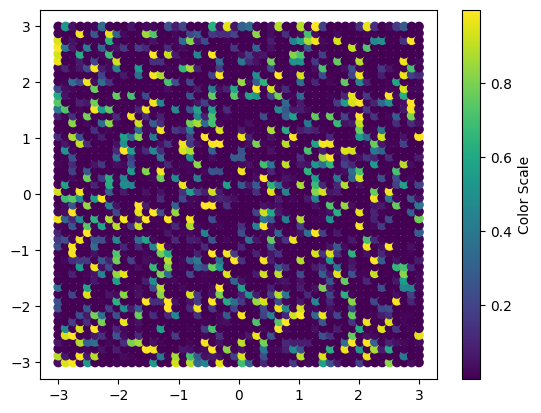

In [286]:

import matplotlib.pyplot as plt

array_2d = y_points.squeeze(axis=-1)  
print(np.shape(array_2d))
softmax = np.exp(array_2d) / np.sum(np.exp(array_2d), axis=1, keepdims=True)
class0_probs = softmax[:,0]

sc = plt.scatter(x_points[:,0,0], x_points[:,1,0], c=class0_probs)
plt.colorbar(sc, label="Color Scale")

In [205]:
int_en = 0
grad_x = np.zeros_like(x) 
for i in range(np.shape(x)[0]):
    grad_x[i] -= sigmoid_prime(x[i]) * b_x[i]
    int_en -= sigmoid(x[i]) * b_x[i]
    for j in range(np.shape(n)[1]):
        grad_x[i] -= sigmoid_prime(x[i]) * sigmoid(n[0, j]) * (w_x[i,j])
        int_en -= w_x[i,j] * sigmoid(x[i]) * sigmoid(n[0, j])
print(int_en)
grad_h = np.zeros_like(n[0,:])
for k in range(np.shape(n)[1]):
    for l in range(np.shape(x)[0]):
        grad_h[k] -= sigmoid_prime(n[0,k]) * sigmoid(x[l]) * (w_x[l, k])


grad_h, grad_x = im.hopfield_interaction_grad(n , x, w_x, b_x, sigmoid, sigmoid_prime, 0, False)
print(im.hopfield_interaction(n , x, w_x, b_x, sigmoid, 0))
print(im.hopfield_2int_grad())


1.2228085529777852
1.2228085529777855


In [ ]:

grad = np.zeros_like(n)
for i in range(n_layers):
    for j in range(n_per_layer):
        grad[i,j] += n[i,j]
        grad[i,j] -= b[i,j] * sigmoid_prime(n[i,j])
        for k in range(n_per_layer):
            if i == 0:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i+1,k]))*(w[i,j,k] + w[i,k,j])
            elif i == range(n_layers)[-1]:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i-1,k]))*(w[i-1,j,k] + w[i-1,k,j])
            else:
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i-1,k]))*(w[i-1,j,k] + w[i-1,k,j])
                grad[i,j] -= 0.5*(sigmoid_prime(n[i,j]))*(sigmoid(n[i+1,k]))*(w[i,j,k] + w[i,k,j])


print(grad)
